<a href="https://colab.research.google.com/github/DeepakM2012/ATS-Project-Sensex/blob/main/ATS_Project_Sensex_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arch hmmlearn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 13.2 MB/s eta 0:00:00


✔ Data loaded  →  shape: (6447, 6)
        Price             Close           High              Low  \
0      Ticker            ^BSESN         ^BSESN           ^BSESN   
1        Date               NaN            NaN              NaN   
2  2000-01-03  5375.10986328125  5384.66015625  5209.5400390625   

              Open  Volume  
0           ^BSESN  ^BSESN  
1              NaN     NaN  
2  5209.5400390625       0  

✔ Date range: 2000-01-03 → 2026-02-20
✔ Log returns computed  →  6444 rows

⏳ Fitting GARCH(1,1) ...
✔ GARCH fitted
                       Zero Mean - GARCH Model Results                        
Dep. Variable:             Log_Return   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -9857.46
Distribution:                  Normal   AIC:                           19720.9
Method:            Maximum Likelihood   BIC:                        

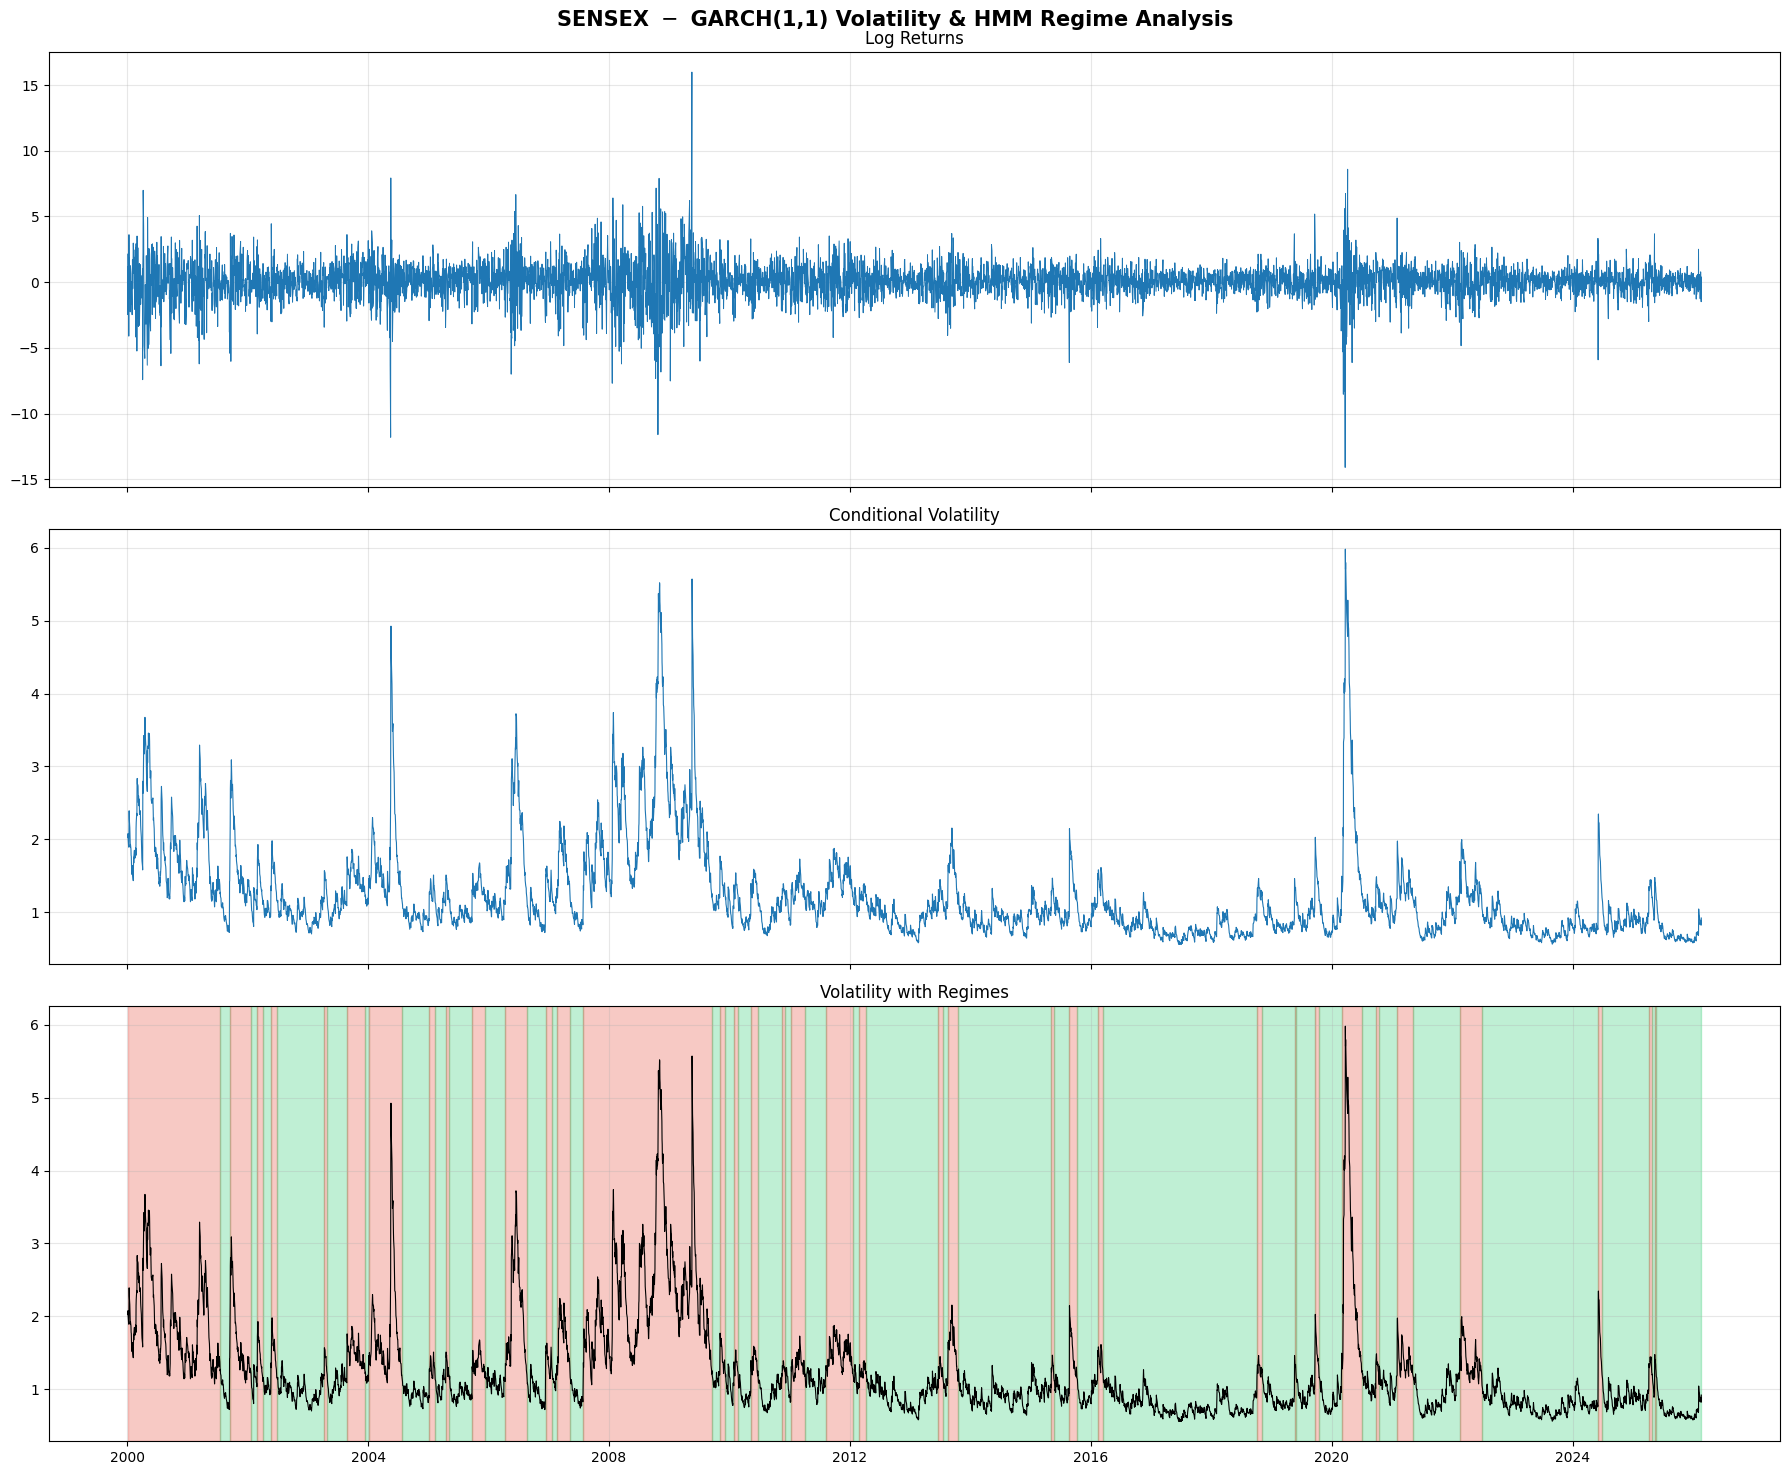

✔ Plot saved → sensex_analysis.png


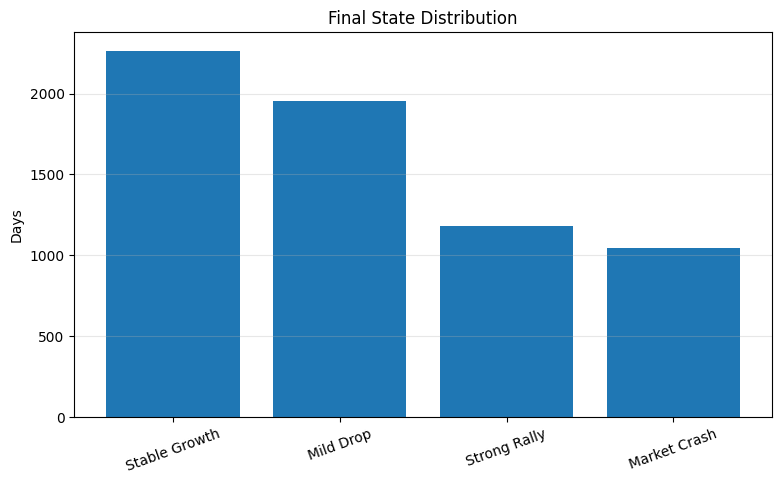

✔ Distribution chart saved → sensex_state_distribution.png


In [ ]:
# =============================================================
#   GARCH + HMM Volatility Regime Pipeline
#   SENSEX DATASET VERSION
# =============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

from arch import arch_model
from hmmlearn.hmm import GaussianHMM

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# STEP 1 : Load CSV
# ─────────────────────────────────────────────────────────────
df = pd.read_csv("sensex_data.csv")
print("✔ Data loaded  →  shape:", df.shape)
print(df.head(3))

# Clean header junk if present
df = df.iloc[2:].copy()
df = df.rename(columns={'Price': 'Date'})

# Convert numeric columns
for col in ['Close','High','Low','Open','Volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ─────────────────────────────────────────────────────────────
# STEP 2 : Parse dates & sort
# ─────────────────────────────────────────────────────────────
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print("\n✔ Date range:", df["Date"].min().date(), "→", df["Date"].max().date())

# ─────────────────────────────────────────────────────────────
# STEP 3 : Keep Date + Close
# ─────────────────────────────────────────────────────────────
df = df[["Date", "Close"]].copy()

# ─────────────────────────────────────────────────────────────
# STEP 4 : Log returns ×100
# ─────────────────────────────────────────────────────────────
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1)) * 100
df.dropna(subset=["Log_Return"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✔ Log returns computed  →  {len(df)} rows")

# ─────────────────────────────────────────────────────────────
# STEP 5 : Fit GARCH(1,1)
# ─────────────────────────────────────────────────────────────
print("\n⏳ Fitting GARCH(1,1) ...")

garch = arch_model(
    df["Log_Return"],
    mean="Zero",
    vol="GARCH",
    p=1,
    q=1
)

garch_result = garch.fit(disp="off")
df["Volatility"] = garch_result.conditional_volatility

print("✔ GARCH fitted")
print(garch_result.summary())

# ─────────────────────────────────────────────────────────────
# STEP 6 : Fit 2-State HMM on Volatility
# ─────────────────────────────────────────────────────────────
print("\n⏳ Fitting HMM ...")

vol_array = df["Volatility"].values.reshape(-1,1)

hmm_model = GaussianHMM(
    n_components=2,
    covariance_type="full",
    n_iter=1000,
    random_state=42
)

hmm_model.fit(vol_array)
raw_states = hmm_model.predict(vol_array)

print("✔ HMM fitted")

# ─────────────────────────────────────────────────────────────
# STEP 7 : Identify High/Low states
# ─────────────────────────────────────────────────────────────
mean_vol_per_state = {
    state: vol_array[raw_states==state].mean()
    for state in np.unique(raw_states)
}

print("\nMean volatility per raw state:", mean_vol_per_state)

high_vol_state = max(mean_vol_per_state, key=mean_vol_per_state.get)
low_vol_state  = min(mean_vol_per_state, key=mean_vol_per_state.get)

print("High volatility state =", high_vol_state)
print("Low volatility state  =", low_vol_state)

df["Vol_Regime_Num"] = np.where(raw_states==high_vol_state,1,0)
df["Vol_Regime"] = df["Vol_Regime_Num"].map({
    0:"Low Volatility",
    1:"High Volatility"
})

# ─────────────────────────────────────────────────────────────
# STEP 8 : Return Sign
# ─────────────────────────────────────────────────────────────
df["Return_Sign"] = np.where(df["Log_Return"]>0,1,-1)

# ─────────────────────────────────────────────────────────────
# STEP 9 : Final 4-State Classification
# ─────────────────────────────────────────────────────────────
def classify_state(v,s):
    if v==0 and s==1: return "Stable Growth"
    if v==0 and s==-1: return "Mild Drop"
    if v==1 and s==1: return "Strong Rally"
    return "Market Crash"

df["Final_State"] = df.apply(
    lambda r: classify_state(r["Vol_Regime_Num"],r["Return_Sign"]),
    axis=1
)

# ─────────────────────────────────────────────────────────────
# STEP 10 : Final Output
# ─────────────────────────────────────────────────────────────
final_df = df[[
    "Date","Log_Return","Volatility",
    "Vol_Regime","Return_Sign","Final_State"
]].copy()

print("\nFINAL DATAFRAME:")
print(final_df.head(15))

final_df.to_csv("sensex_final_output.csv",index=False)
print("\n✔ Saved → sensex_final_output.csv")

# ─────────────────────────────────────────────────────────────
# STEP 11 : PLOTS
# ─────────────────────────────────────────────────────────────

COLOR_LOW  = "#2ecc71"
COLOR_HIGH = "#e74c3c"

dates = final_df["Date"].values
returns = final_df["Log_Return"].values
vol = final_df["Volatility"].values
reg = df["Vol_Regime_Num"].values

fig,axes = plt.subplots(3,1,figsize=(18,15),sharex=True)

fig.suptitle(
    "SENSEX  ─  GARCH(1,1) Volatility & HMM Regime Analysis",
    fontsize=15,fontweight="bold"
)

# Panel 1
axes[0].plot(dates,returns,linewidth=0.7)
axes[0].set_title("Log Returns")
axes[0].grid(True,alpha=0.3)

# Panel 2
axes[1].plot(dates,vol,linewidth=0.8)
axes[1].set_title("Conditional Volatility")
axes[1].grid(True,alpha=0.3)

# Panel 3 with shading
i,n = 0,len(dates)
while i<n:
    j=i
    while j<n and reg[j]==reg[i]:
        j+=1
    color = COLOR_LOW if reg[i]==0 else COLOR_HIGH
    axes[2].axvspan(dates[i],dates[min(j,n-1)],alpha=0.3,color=color)
    i=j

axes[2].plot(dates,vol,color="black",linewidth=0.8)
axes[2].set_title("Volatility with Regimes")
axes[2].grid(True,alpha=0.3)

plt.tight_layout()
plt.savefig("sensex_analysis.png",dpi=150)
plt.show()

print("✔ Plot saved → sensex_analysis.png")

# ─────────────────────────────────────────────────────────────
# BONUS : State Distribution
# ─────────────────────────────────────────────────────────────
counts = final_df["Final_State"].value_counts()

plt.figure(figsize=(9,5))
plt.bar(counts.index,counts.values)
plt.title("Final State Distribution")
plt.ylabel("Days")
plt.xticks(rotation=20)
plt.grid(axis="y",alpha=0.3)

plt.savefig("sensex_state_distribution.png",dpi=150)
plt.show()

print("✔ Distribution chart saved → sensex_state_distribution.png")